## Analysis Workflow
This workflow presents the analytical process used to explore the dataset and answer the business questions. The workflow includes time series exploration, descriptive statistics using Numpy, and inferential statistical testing.

In [1]:
# import the necessary package 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# use preprocessed data
df_cleaned = pd.read_csv('preprocessed_retail_data.csv')
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12


#### Time Series Exploration and Trend Analysis

In [4]:
# aggregate monthly revenue
monthly_revenue = (
    df_cleaned.groupby(['Year', 'Month'])['Revenue']
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Year,Month,Revenue
0,2010,12,374853.550
1,2011,1,316001.930
2,2011,2,299159.990
3,2011,3,393501.535
4,2011,4,325333.481


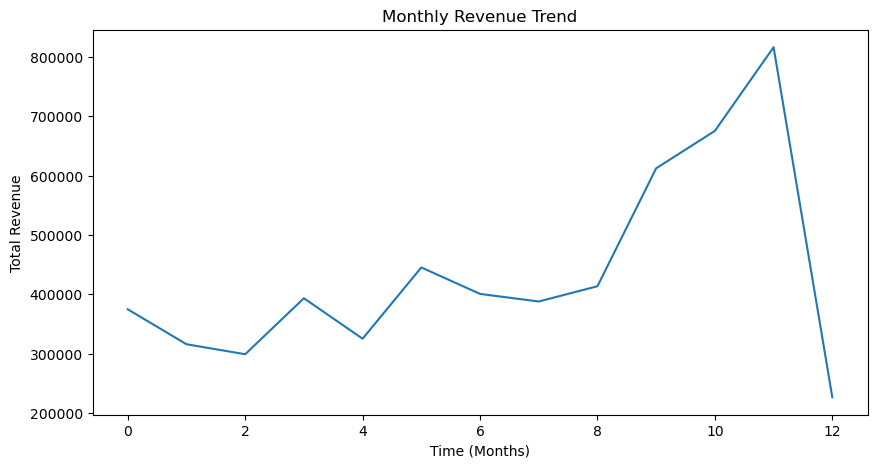

In [5]:
# visualization
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue.index, monthly_revenue['Revenue'])
plt.title('Monthly Revenue Trend')
plt.xlabel('Time (Months)')
plt.ylabel('Total Revenue')
plt.show()

Plot Interpretation:
Monthly revenue in the earlier months, followed by an upward movement from around month 8, with revenue peaking in month 11. It suggests stronger sales performance towards the end of the year. Month 12 shows an obvious decline compared to the previous months, indicating a change in revenue level duribg that period.
Overall, the trend provides insight into when the business performs best across the year.

#### Descriptive statistics
This is done to summarize the distribution of transaction revenue and understand purchase values

In [6]:
# determine the skewness of the data using statistiacl means
mean_rev = np.mean(df_cleaned['Revenue'])
median_rev = np.median(df_cleaned['Revenue'])
std_rev = np.std(df_cleaned['Revenue'])

q25, q50, q75 = np.percentile(df_cleaned['Revenue'], [25, 50, 75])

mean_rev, median_rev, std_rev, q25, q50, q75

(14.483714537092682, 12.45, 11.916124573373272, 4.949999999999999, 12.45, 19.8)

Interpretation: The average revenue per transaction is higher than the median, which means most purchases are small to moderate, while a few large purchases increase the overall average. Most transactions fall between low and mid-range values, with fewer high-value purchases. This indicates a right-skewed distribution, where a small number of big transactions contribute heavily to total revenue.

#### Inferential Statistics
Case study: The Management seeks to understand whether customer loyalty is a true driver of revenue. In particular, the analysis tests whether repeat customers generate significantly higher revenue than one-time customers.

In [11]:
from scipy.stats import ttest_ind 

purchase_counts = df_cleaned.groupby('CustomerID')['InvoiceNo'].nunique()
df_cleaned['CustomerType'] = df_cleaned['CustomerID'].map(
    lambda x: 'Repeat' if purchase_counts[x] > 1 else 'One-time'
) 

repeat_rev = df_cleaned[df_cleaned['CustomerType']=="Repeat"]['Revenue']
one_time_rev = df_cleaned[df_cleaned['CustomerType']=="One-time"]['Revenue'] 

t_stat, p_value = ttest_ind(repeat_rev, one_time_rev, equal_var=False)

t_stat, p_value

(23.007540048617006, 2.1521382244802701e-116)

Interpretation: The independent t-test shows a statistically significant difference in revenue between repeat and one-time customers (p < 0.05).The t-statistic is large and positive (t = 23.01), showing that repeat customers have a higher average revenue than one-time customers. The p-value is extremely small (p ≈ 0), meaning this difference is not due to random chance. This confirms that customer loyalty is a strong driver of revenue for the business.

## Business Questions/ Insights

#### 1. What factors are associated with higher revenue?

In [13]:
# determine the top products
top_products = (
    df_cleaned.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
) 

top_products

,Description,Revenue
0,REGENCY CAKESTAND 3 TIER,50701.435
1,WHITE HANGING HEART T-LIGHT HOLDER,44941.235
2,POSTAGE,37893.145
3,JUMBO BAG RED RETROSPOT,37021.725
4,PARTY BUNTING,35107.365
5,ASSORTED COLOUR BIRD ORNAMENT,33409.625
6,SPOTTY BUNTING,22284.900
7,JAM MAKING SET WITH JARS,21950.255
8,PAPER CHAIN KIT 50'S CHRISTMAS,21813.725
9,LUNCH BAG RED RETROSPOT,20738.900


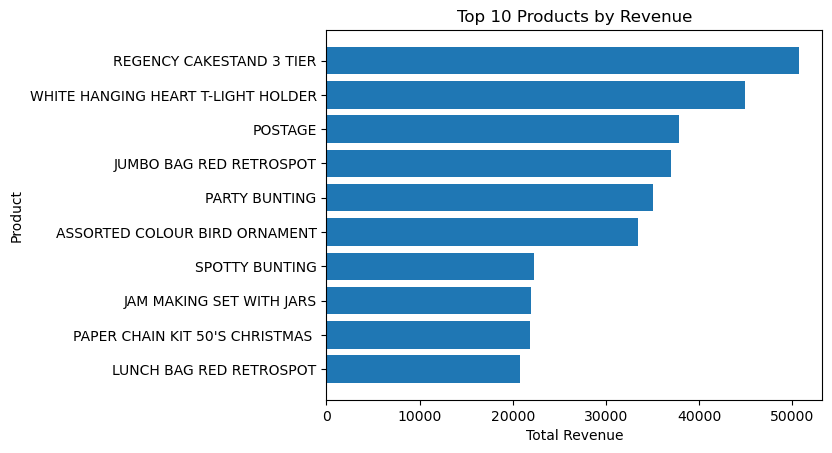

In [14]:
# visualization
plt.figure()
plt.barh(top_products['Description'], top_products['Revenue'])
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")
plt.gca().invert_yaxis()
plt.show()

Interpretation:
Most revenue comes from a few top-selling products such as Regency Cake Stand 3 Tier, White Hanging Heart T-Light Holder, and Jumbo Bag Red Retrospot. Focusing on these items can significantly improve overall sales.

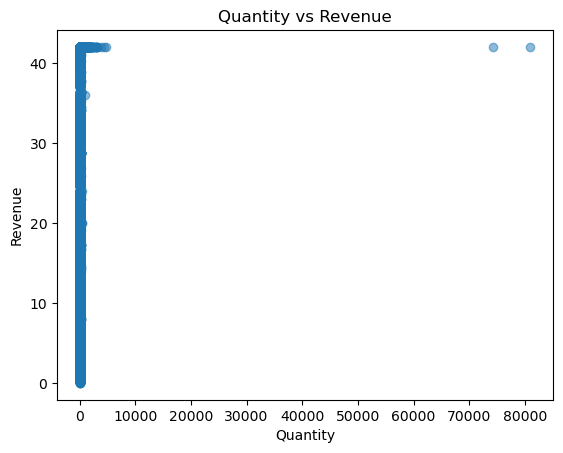

In [16]:
# what does quantity have to do with Revenue? Quantity vs Revenue
plt.figure()
plt.scatter(df_cleaned['Quantity'], df_cleaned['Revenue'], alpha=0.5)
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue")
plt.show()

Interpretation: Revenue increases as quantity increases, this shows a positive relationship. Most purchases are small, but a few very large quantity orders generate much higher revenue.

#### 2. Do Repeat customers generate more revenue than one-time customer?

In [17]:
# Average Revenue by Customer type

avg_rev_type = df_cleaned.groupby('CustomerType')['Revenue'].mean().reset_index()
avg_rev_type

,CustomerType,Revenue
0,One-time,13.174043
1,Repeat,14.603465


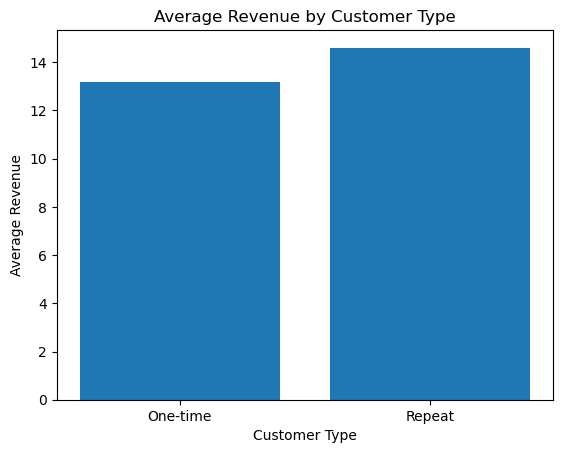

In [18]:
# visualization

plt.figure()
plt.bar(avg_rev_type['CustomerType'], avg_rev_type['Revenue'])
plt.xlabel("Customer Type")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Customer Type")
plt.show()

Interpretation: Repeat customers generate higher average revenue than one-time customers. It shows that customer loyalty is an important driver of revenue. 

#### 3. Which countries contribute the most to total revenue?

In [19]:
# Total Revenue by Country

country_revenue = (
    df_cleaned.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

country_revenue

,Country,Revenue
0,United Kingdom,4757728.289
1,Germany,179253.505
2,France,161657.770
3,EIRE,153970.195
4,Netherlands,81706.915
5,Switzerland,41223.700
6,Spain,41167.340
7,Belgium,38118.765
8,Australia,37717.935
9,Portugal,26043.905


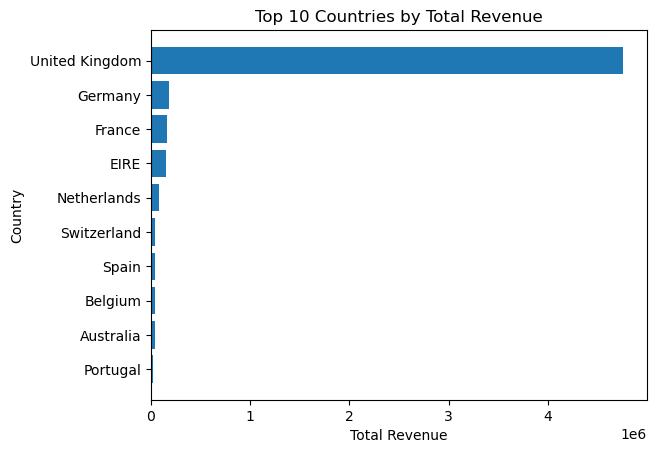

In [20]:
# Visualization

plt.figure()
plt.barh(country_revenue['Country'], country_revenue['Revenue'])
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.title("Top 10 Countries by Total Revenue")
plt.gca().invert_yaxis()
plt.show()

Interpretation: The United Kingdom contributes the majority of total revenue, far exceeding other countries.
This suggests the business is heavily dependent on the UK market, while other countries currently play a much smaller role in revenue generation.

